In [81]:
## Import the importent laibrary
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message="X has feature names")


In [2]:
df = pd.read_csv(r"\Users\Mansi\Downloads\HR_file.csv")

In [3]:
print(df.head())
print(df.info())
print(df.describe())


   Satisfaction Level  Last Evaluation  Number of Projects  Monthly Hours  \
0                0.38             0.53                   2            157   
1                0.80             0.86                   5            262   
2                0.11             0.88                   7            272   
3                0.72             0.87                   5            223   
4                0.37             0.52                   2            159   

   Total Time at the Company  Work Accidents  Quit the Company  \
0                          3               0                 1   
1                          6               0                 1   
2                          4               0                 1   
3                          5               0                 1   
4                          3               0                 1   

   Promoted in Last 5 yrs Departments   salary  Management  
0                       0        sales     low          31  
1                 

## Remove Unnecessary Columns

In [15]:
df.drop('Management', axis=1, inplace=True)


## Clean Column Names (Remove Extra Spaces)

In [5]:
# Create a cleaned list of column names
cleaned_cols = []
for col in df.columns:
    cleaned_cols.append(col.strip())

# Assign back to DataFrame
df.columns = cleaned_cols

In [6]:
df['Departments'].unique()

array(['sales', 'accounting', 'hr', 'technical', 'support', 'management',
       'IT', 'product_mng', 'marketing', 'RandD'], dtype=object)

In [12]:
df['salary'].unique()

array([1, 2, 0])

## Fix Department Name Inconsistencies 

In [7]:
df['Departments'] = df['Departments'].replace({
    'sales': 'Sales',
    'accounting': 'Accounting',
    'hr': 'Human Resources',
    'technical': 'Technical',
    'support': 'Support',
    'management': 'Management',
    'IT': 'Information Technology',
    'product_mng': 'Product Management',
    'marketing': 'Marketing',
    'RandD': 'R&D'
})


## Check for Missing (Null) Values

In [17]:
df.isnull().sum()


Satisfaction Level           0
Last Evaluation              0
Number of Projects           0
Monthly Hours                0
Total Time at the Company    0
Work Accidents               0
Quit the Company             0
Promoted in Last 5 yrs       0
Departments                  0
salary                       0
dtype: int64

## Convert Categorical Columns to Numeric Format

In [10]:
le = LabelEncoder()
df['Departments'] = le.fit_transform(df['Departments'])
df['salary'] = le.fit_transform(df['salary'])

## Detect and Analyze Outliers

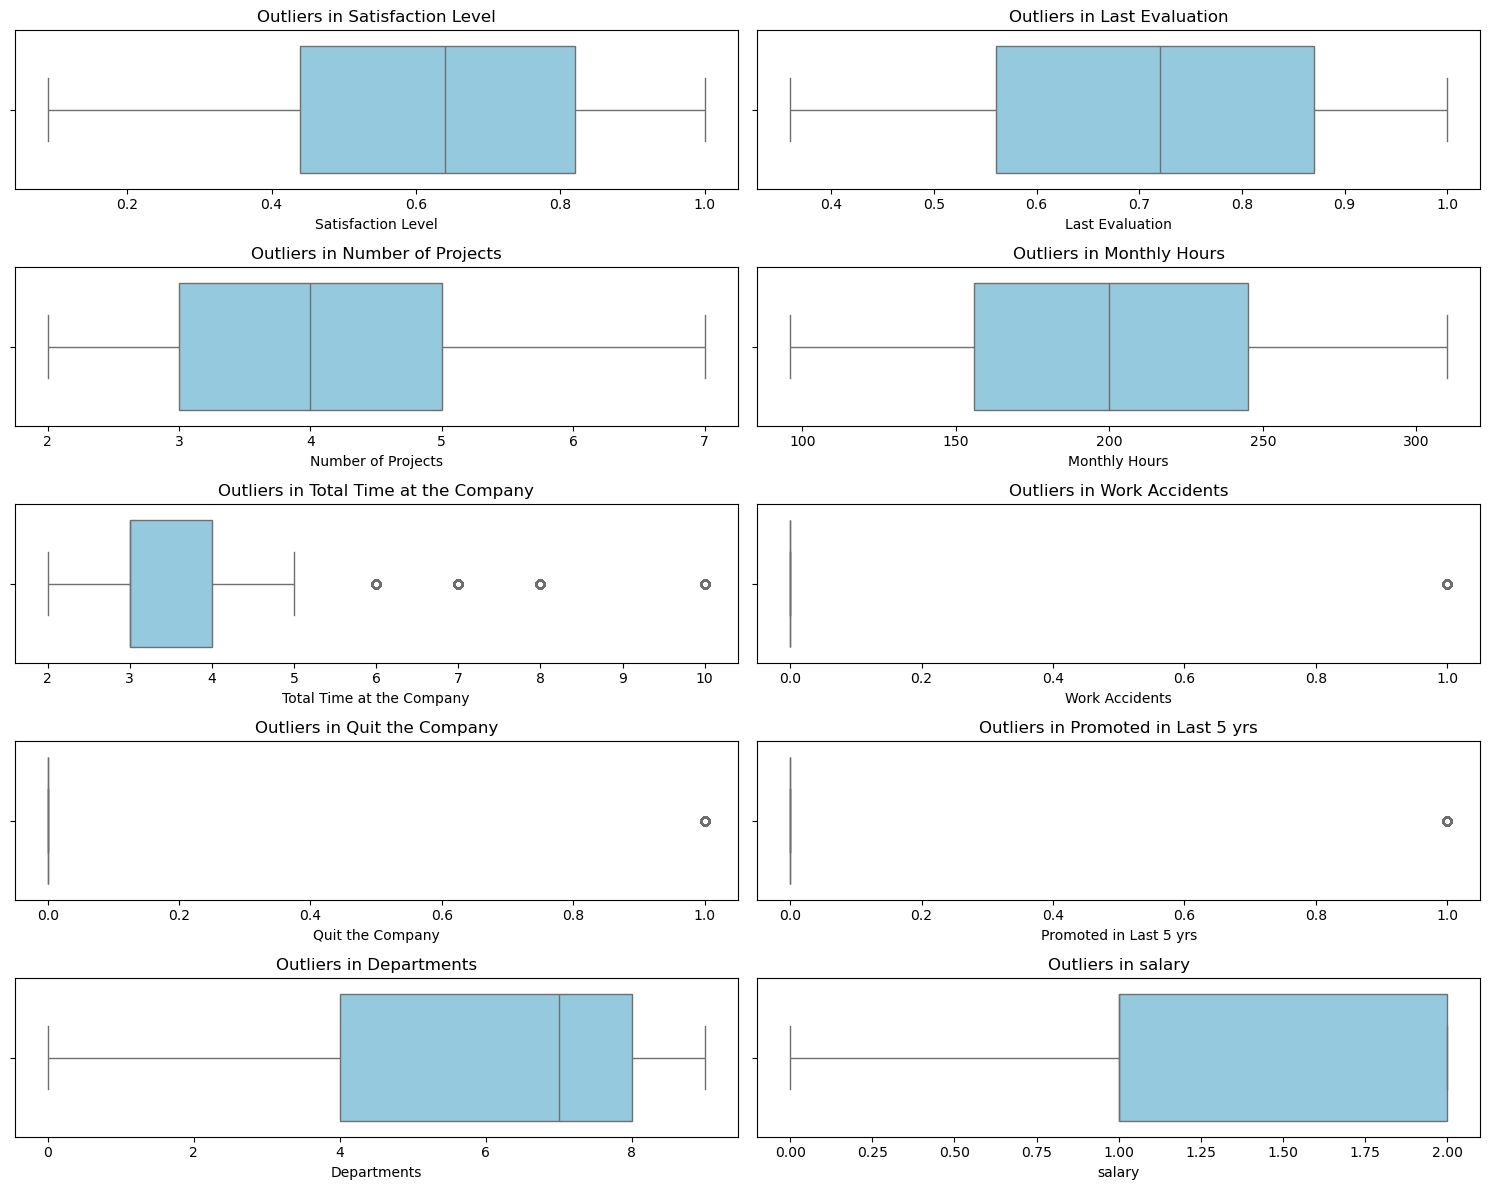

In [144]:
plt.figure(figsize=(15,12))
for i, col in enumerate([
    "Satisfaction Level", "Last Evaluation", "Number of Projects", 
    "Monthly Hours", "Total Time at the Company", "Work Accidents", 
    "Quit the Company", "Promoted in Last 5 yrs", "Departments", "salary"
], 1):
    plt.subplot(5, 2, i)   # 5 rows, 2 columns = 10 slots
    sns.boxplot(x=df[col], color="skyblue")
    plt.title(f"Outliers in {col}")

plt.tight_layout()
plt.show()


### Boxplot Analysis Summary

- **Employee Tenure:** Most employees have worked between **5–10 years**, and there are **no extreme outliers**, showing a **stable retention trend**.  
- **Workload (Monthly Hours & Number of Projects):** Some employees work **much more than average**, which could indicate a **risk of burnout**.  
- **Satisfaction & Evaluation Scores:** These values are **well-balanced** with **no unusual patterns**.  
- **Departments & Salary:** Both are **evenly distributed** with **no major outliers**.  
- **Overall Observation:** From the boxplot analysis, it is clear that there are **no extreme outliers** in the dataset, indicating **clean and reliable data** for further analysis.  


##  Define Features and Target Variable

In [20]:
# Define features and target
X = df.drop('Quit the Company', axis=1)
y = df['Quit the Company']

## Split Data into Training and Testing Sets

In [24]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Print shapes to understand the split
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# Optional: check class balance in train vs test
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X: (14999, 9)
Shape of y: (14999,)
Shape of X_train: (11999, 9)
Shape of X_test: (3000, 9)
Shape of y_train: (11999,)
Shape of y_test: (3000,)

Class distribution in y_train:
Quit the Company
0    0.76123
1    0.23877
Name: proportion, dtype: float64

Class distribution in y_test:
Quit the Company
0    0.764667
1    0.235333
Name: proportion, dtype: float64


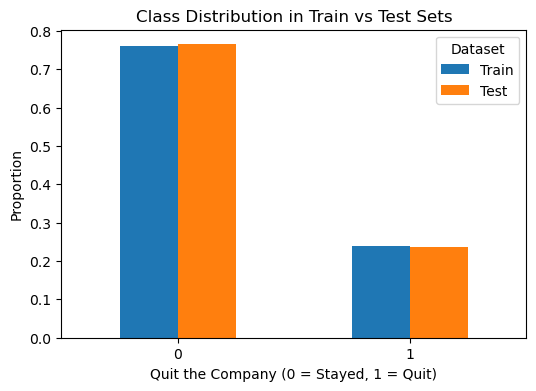

In [25]:
# Put your proportions into a DataFrame for easy plotting
train_dist = y_train.value_counts(normalize=True).rename("Train")
test_dist = y_test.value_counts(normalize=True).rename("Test")
dist_df = pd.concat([train_dist, test_dist], axis=1)
# Plot
dist_df.plot(kind="bar", figsize=(6,4))
plt.title("Class Distribution in Train vs Test Sets")
plt.xlabel("Quit the Company (0 = Stayed, 1 = Quit)")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(title="Dataset")
plt.show()

###  Class Distribution in Train vs Test Sets

This chart compares the proportion of employees who **stayed (0)** versus those who **quit (1)** in both the training and test datasets.

- In the **training set**, about **76% stayed** and **24% quit**.  
- In the **test set**, about **76.5% stayed** and **23.5% quit**.  
- The bars are almost identical in height, which means the **class balance is consistent** across both splits.

 This is important because it ensures the model is trained and tested on data with the **same distribution of outcomes**, making the evaluation fair and reliable.


## Apply Feature Scaling
-  Scale features to improve model performance.

In [39]:
## Feature Scaling
## Scale features to improve model performance.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Build the Logistic Regression Model

In [40]:
## Build the Logistic Regression Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

## Make Predictions on Test Data

In [41]:
## Make Predictions
y_pred = model.predict(X_test_scaled)

## Plot the Confusion Matrix

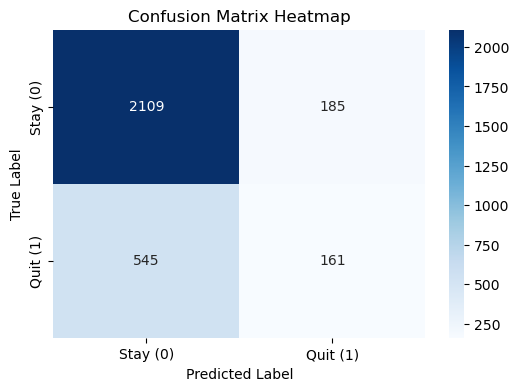

In [42]:
# Get confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stay (0)', 'Quit (1)'], 
            yticklabels=['Stay (0)', 'Quit (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

###  Confusion Matrix Explanation

The confusion matrix compares the **actual outcomes** (employees who stayed or quit) with the **model’s predictions**:

- **2109 (Top‑left)** → Employees who actually stayed, and the model correctly predicted *Stayed* (**True Negatives**).  
- **185 (Top‑right)** → Employees who actually stayed, but the model wrongly predicted *Quit* (**False Positives**).  
- **545 (Bottom‑left)** → Employees who actually quit, but the model wrongly predicted *Stayed* (**False Negatives**).  
- **161 (Bottom‑right)** → Employees who actually quit, and the model correctly predicted *Quit* (**True Positives**).  

---

### What this means
- The model is **very accurate at predicting who stayed** (2109 correct vs 185 mistakes).  
- The model is **weaker at predicting who quit** (161 correct vs 545 missed).  
- In other words, it’s **better at identifying loyal employees** than those likely to leave.  

---

###  Why it matters
If the business goal is to **reduce attrition**, the model needs improvement in catching employees who are at risk of quitting (reducing false negatives). Improving recall for the *Quit* class would make the model more useful for HR decision‑making.


## Evaluate Model Performance


In [43]:
## Evaluate Model Performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7566666666666667
Confusion Matrix:
 [[2109  185]
 [ 545  161]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85      2294
           1       0.47      0.23      0.31       706

    accuracy                           0.76      3000
   macro avg       0.63      0.57      0.58      3000
weighted avg       0.72      0.76      0.72      3000



###  Model Performance Summary

**Accuracy = 0.76 (76%)**  
 Overall, the model is correct about 3 out of 4 times.

---

#### Class 0 (Stayed)
- **Precision = 0.79** → When the model predicts *Stayed*, it’s right 79% of the time.  
- **Recall = 0.92** → It correctly identifies 92% of employees who actually stayed.  
- **F1 = 0.85** → Very strong performance here.  

---

#### Class 1 (Quit)
- **Precision = 0.47** → When the model predicts *Quit*, it’s only right 47% of the time.  
- **Recall = 0.23** → It only catches 23% of employees who actually quit.  
- **F1 = 0.31** → Weak performance here.  

---

###  The Problem
- The model is **biased toward predicting “Stayed” (0)**.  
- It **misses many employees who actually quit** (high false negatives).  
- That’s why recall for class 1 is very low (0.23).  

---

 **Takeaway:** The model is strong at identifying employees who stay, but it struggles to detect those who quit. Improving **recall and F1‑score for the “Quit” class** should be the next focus.


## Optimize the Decision Threshold
- improves model performance (like accuracy, precision, recall, or F1-score) depending on your business goal.

In [108]:
# Tune decision threshold
y_pred_proba = model.predict_proba(X_test_scaled)[:,1]
threshold = 0.3
y_pred_custom = (y_pred_proba >= threshold).astype(int)
# Evaluate performance
print("Confusion Matrix (Threshold = 0.3):")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report (Threshold = 0.3):")
print(classification_report(y_test, y_pred_custom))

Confusion Matrix (Threshold = 0.3):
[[1866  428]
 [ 223  483]]

Classification Report (Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.89      0.81      0.85      2294
           1       0.53      0.68      0.60       706

    accuracy                           0.78      3000
   macro avg       0.71      0.75      0.72      3000
weighted avg       0.81      0.78      0.79      3000



###  Threshold Tuning: Before vs After

The table below compares model performance at the default threshold (0.5) and the tuned threshold (0.3):

| Metric                | Threshold = 0.5 | Threshold = 0.3 |
|------------------------|-----------------|-----------------|
| **Accuracy**           | 0.76            | 0.78            |
| **Precision (Stayed)** | 0.79            | 0.89            |
| **Recall (Stayed)**    | 0.92            | 0.81            |
| **F1 (Stayed)**        | 0.85            | 0.85            |
| **Precision (Quit)**   | 0.47            | 0.53            |
| **Recall (Quit)**      | 0.23            | 0.68            |
| **F1 (Quit)**          | 0.31            | 0.60            |

---

###  Key Insights
- **Recall for Quit (class 1)** jumped from **0.23 → 0.68**, meaning the model now catches far more employees who actually quit.  
- **F1 for Quit** improved from **0.31 → 0.60**, showing a much better balance between precision and recall.  
- **Accuracy** improved slightly (0.76 → 0.78).  
- Trade‑off: The model now raises more false alarms (predicting some stayers as quitters), but this is often acceptable in HR contexts where **missing quitters is more costly**.  

---

 **Takeaway:** Lowering the threshold made the model far more useful for attrition prediction, because it now identifies many more employees at risk of leaving.



In [52]:
comparison = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted (0.3 threshold)": y_pred_custom
})

# Show fir)t 20 rows
comparison.head(20)

,Actual,Predicted (0.3 threshold)
0,0,0
1,0,0
2,0,0
3,1,1
4,0,0
5,0,0
6,0,0
7,0,1
8,0,0
9,0,1


## Apply Model on Unseen Data (New Inputs)

In [128]:
import pandas as pd

# 1. Create unseen data (exclude 'Quit the Company' since it's the target)
unseen_data = pd.DataFrame({
    'Satisfaction Level': [0.45, 0.80, 0.25, 0.95],
    'Last Evaluation':    [0.70, 0.95, 0.40, 0.88],
    'Number of Projects': [3,    6,    2,    5],
    'Monthly Hours':      [160,  250,  120,  210],
    'Total Time at the Company': [3, 8, 1, 12],
    'Work Accidents':     [0,    1,    0,    0],
    'Promoted in Last 5 yrs': [0, 0, 0, 1],
    'Departments':        ['Sales', 'Technical', 'Support', 'HR'],
    'salary':             ['low', 'medium', 'high', 'high']
})

# If you already fitted encoders during training, load/reuse them instead of fitting again
unseen_data['Departments'] = le.fit_transform(unseen_data['Departments'])
unseen_data['salary'] = le.fit_transform(unseen_data['salary'])




# 3. Predict probabilities
y_pred_proba = model.predict_proba(unseen_data)[:, 1]


# 4. Scale numeric + categorical
unseen_data_scaled = scaler.transform(unseen_data)

# 5. Predict
y_pred_proba = model.predict_proba(unseen_data_scaled)[:, 1]
threshold = 0.3
y_pred_custom = (y_pred_proba >= threshold).astype(int)

# 6. Combine results
results_df = unseen_data.copy()
results_df['Attrition_Prob'] = y_pred_proba
results_df['Attrition_Pred'] = y_pred_custom

print(results_df)


   Satisfaction Level  Last Evaluation  Number of Projects  Monthly Hours  \
0                0.45             0.70                   3            160   
1                0.80             0.95                   6            250   
2                0.25             0.40                   2            120   
3                0.95             0.88                   5            210   

   Total Time at the Company  Work Accidents  Promoted in Last 5 yrs  \
0                          3               0                       0   
1                          8               1                       0   
2                          1               0                       0   
3                         12               0                       1   

   Departments  salary  Attrition_Prob  Attrition_Pred  
0            1       1        0.316436               1  
1            3       2        0.057079               0  
2            2       0        0.376593               1  
3            0       0   

## Review the Result DataFrame for Better Interpretation

In [145]:
results_df

,Satisfaction Level,Last Evaluation,Number of Projects,Monthly Hours,Total Time at the Company,Work Accidents,Promoted in Last 5 yrs,Departments,salary,Attrition_Prob,Attrition_Pred
0,0.45,0.70,3,160,3,0,0,1,1,0.316436,1
1,0.80,0.95,6,250,8,1,0,3,2,0.057079,0
2,0.25,0.40,2,120,1,0,0,2,0,0.376593,1
3,0.95,0.88,5,210,12,0,1,0,0,0.053935,0
